### Wstęp do Uczenia Maszynowego - praca domowa 3
##### Stanisław Frelik
##### 11.12.2023

### CZĘŚĆ PIERWSZA
---------

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.model_selection import train_test_split
import random
import copy
from matplotlib.colors import ListedColormap

In [263]:
def knn(X, y, Z, k, p = 2):
    # opis
    
    # testy
    
    X = pd.DataFrame(X)
    y = np.array(y)
    Z = pd.DataFrame(Z)
    categorical_features_X = list(X.dtypes[(X.dtypes == 'object') | (X.dtypes == 'category')].index)
    categorical_features_Z = list(Z.dtypes[(Z.dtypes == 'object') | (Z.dtypes == 'category')].index)
    X = X.drop(categorical_features_X, axis = 1)
    Z = Z.drop(categorical_features_Z, axis = 1)
    if not (type(y[0]) == np.int32 or type(y[0]) == np.float64): 
        raise ValueError("y categorical :(")
    n_X, p_X = X.shape
    n = len(y)
    n_Z, p_Z = Z.shape
    if p_X == 0 or p_Z == 0:
        raise ValueError("X or Z has categorical attributes")
    if not(p_X == p_Z):
        raise ValueError("X and Z wrong size")
    if not(n == n_X):
        raise ValueError("X and y wrong size")
    if not isinstance(k, int):
        raise ValueError("k is not an int")
    if not (1<=k and k <= n):
        raise ValueError("k not in [1,n]")
    if not p == np.inf:
        if not isinstance(p, (int, float)):
            raise ValueError("p not a real number")
        elif p < 1:
            raise ValueError("p to small :(")
        
    # normalizacja, żeby było lepiej :)
    
    for i in range(0, n_X):
        m, s = np.mean(np.array(X.iloc[i])), np.std(np.array(X.iloc[i]))
        for j in range(0, p_X):
            X.iloc[i, j] = (X.iloc[i, j] - m)/s
    for i in range(0, n_Z):
        m, s = np.mean(np.array(Z.iloc[i])), np.std(np.array(Z.iloc[i]))
        for j in range(0, p_Z):
            Z.iloc[i, j] = (Z.iloc[i, j] - m)/s
    
    # treść
        
    w = []
    if p == np.inf:
        for i in range(0, n_Z):
            d = np.zeros(n_X)
            l = []
            for j in range(0, n_X):  
                h = np.zeros(p_X)
                for q in range(0, p_X):
                        h[q] = (abs(Z.iloc[i, q] - X.iloc[j, q]))
                d[j] = max(h)
            d_index = list(enumerate(d))
            d_sort = sorted(d_index, key = lambda x: x[1])
            l = [item[0] for item in d_sort]
            l = l[:k]
            y_closest = [y[i] for i in l]
            unique, counts = np.unique(y_closest, return_counts=True)
            u = unique[counts == max(counts)]
            if len(u) == 1:
                w.append(u[0])
            else:
                rand = random.randint(0, len(u) - 1)
                w.append(u[rand])
    else:
        for i in range(0, n_Z):
            d = np.zeros(n)
            l = []
            for j in range(0, n_X):  
                for q in range(0, p_X):
                    d[j] += (abs(Z.iloc[i, q] - X.iloc[j, q]))**p
                d[j] = d[j]**(1/p)
            d_index = list(enumerate(d))
            d_sort = sorted(d_index, key = lambda x: x[1])
            l = [item[0] for item in d_sort]
            l = l[:k]
            y_closest = [y[i] for i in l]
            unique, counts = np.unique(y_closest, return_counts=True)
            u = unique[counts == max(counts)]
            if len(u) == 1:
                w.append(u[0])
            else:
                rand = random.randint(0, len(u) - 1)
                w.append(u[rand])
    return w


#### CZĘŚĆ DRUGA
--------

Testy w R^2

Dla dwóch klas rozdzielonych

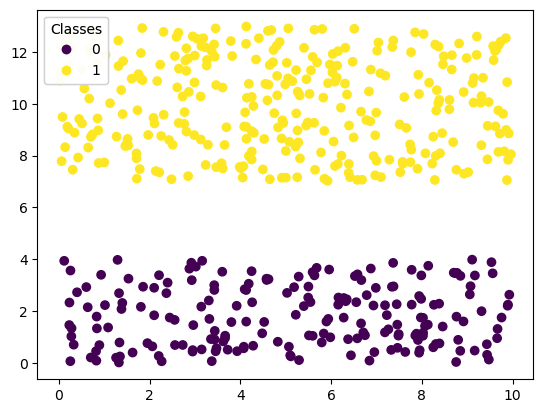

In [282]:
n = 500
x = np.random.uniform(low=0, high=10, size=n)
y = np.random.uniform(low=0, high=10, size=n)
p = 8 - y
p[np.where(p < 4)] = 1
p[np.where(p >= 4)] = 0
for i in range(n):
    if 8 - y[i] < 4:
        y[i] += 3
df = pd.DataFrame({'x': x, 'y': y})
X, Z, y_train, y_test = train_test_split(df, p, test_size = 0.3, random_state=69)

fig, ax = plt.subplots()
scatter = ax.scatter(x, y, c = p)
legend1 = ax.legend(*scatter.legend_elements(),
                    loc="upper left", title="Classes")
ax.add_artist(legend1)

Odtwarzanie:

In [283]:
for p in [1, 2, np.inf]:
    unique, counts = np.unique(knn(X, y_train, X, 1, p) == y_train, return_counts=True)
    print(f"Stosunek poprawnych zaklasyfikowań dla p = {p}: {round(counts[1] / (counts[0] + counts[1]), 3)}")

Stosunek poprawnych zaklasyfikowań dla p = 1: 0.906
Stosunek poprawnych zaklasyfikowań dla p = 2: 0.906
Stosunek poprawnych zaklasyfikowań dla p = inf: 0.906


L1:

In [277]:
k_list = [1, 2, 5, 7, 10, 25, 35, 65, 100]
for k in k_list:
    unique, counts = np.unique(knn(X, y_train, Z, k, 1) == y_test, return_counts=True)
    print(f"Stosunek poprawnych zaklasyfikowań dla k = {k}: {round(counts[1] / (counts[0] + counts[1]), 3)}")

Stosunek poprawnych zaklasyfikowań dla k = 1: 0.827
Stosunek poprawnych zaklasyfikowań dla k = 2: 0.833
Stosunek poprawnych zaklasyfikowań dla k = 5: 0.84
Stosunek poprawnych zaklasyfikowań dla k = 7: 0.827
Stosunek poprawnych zaklasyfikowań dla k = 10: 0.847
Stosunek poprawnych zaklasyfikowań dla k = 25: 0.847
Stosunek poprawnych zaklasyfikowań dla k = 35: 0.847
Stosunek poprawnych zaklasyfikowań dla k = 65: 0.847
Stosunek poprawnych zaklasyfikowań dla k = 100: 0.847


L2:

In [219]:
k_list = [1, 2, 5, 7, 10, 25, 35, 65, 100]
for k in k_list:
    unique, counts = np.unique(knn(X, y_train, Z, k, 2) == y_test, return_counts=True)
    print(f"Stosunek poprawnych zaklasyfikowań dla k = {k}: {round(counts[1] / (counts[0] + counts[1]), 3)}")

Stosunek poprawnych zaklasyfikowań dla k = 1: 0.913
Stosunek poprawnych zaklasyfikowań dla k = 2: 0.86
Stosunek poprawnych zaklasyfikowań dla k = 5: 0.92
Stosunek poprawnych zaklasyfikowań dla k = 7: 0.92
Stosunek poprawnych zaklasyfikowań dla k = 10: 0.913
Stosunek poprawnych zaklasyfikowań dla k = 25: 0.913
Stosunek poprawnych zaklasyfikowań dla k = 35: 0.913
Stosunek poprawnych zaklasyfikowań dla k = 65: 0.913
Stosunek poprawnych zaklasyfikowań dla k = 100: 0.913


L_inf:

In [220]:
k_list = [1, 2, 5, 7, 10, 25, 35, 65, 100]
for k in k_list:
    unique, counts = np.unique(knn(X, y_train, Z, k, np.inf) == y_test, return_counts=True)
    print(f"Stosunek poprawnych zaklasyfikowań dla k = {k}: {round(counts[1] / (counts[0] + counts[1]), 3)}")

Stosunek poprawnych zaklasyfikowań dla k = 1: 0.907
Stosunek poprawnych zaklasyfikowań dla k = 2: 0.847
Stosunek poprawnych zaklasyfikowań dla k = 5: 0.92
Stosunek poprawnych zaklasyfikowań dla k = 7: 0.92
Stosunek poprawnych zaklasyfikowań dla k = 10: 0.913
Stosunek poprawnych zaklasyfikowań dla k = 25: 0.913
Stosunek poprawnych zaklasyfikowań dla k = 35: 0.913
Stosunek poprawnych zaklasyfikowań dla k = 65: 0.913
Stosunek poprawnych zaklasyfikowań dla k = 100: 0.913


----------------------------------------------------------------------------------------------------

Mniej separacji, więcej klas:

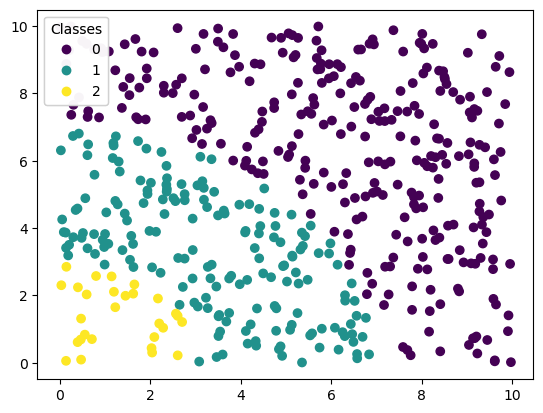

In [284]:
n = 500
x = np.random.uniform(low=0, high=10, size=n)
y = np.random.uniform(low=0, high=10, size=n)
d = np.sqrt(x**2 + y**2)
dd = copy.copy(d)
dd[np.where(d < 7)] = 1
dd[np.where(d >= 7)] = 0
dd[np.where(d < 3)] = 2
df = pd.DataFrame({'x': x, 'y': y})
X, Z, y_train, y_test = train_test_split(df, dd, test_size = 0.3, random_state=69)

fig, ax = plt.subplots()
scatter = ax.scatter(x, y, c = dd)
legend1 = ax.legend(*scatter.legend_elements(),
                    loc="upper left", title="Classes")
ax.add_artist(legend1)

Odtwarzanie:

In [285]:
for p in [1, 2, np.inf]:
    unique, counts = np.unique(knn(X, y_train, X, 1, p) == y_train, return_counts=True)
    print(f"Stosunek poprawnych zaklasyfikowań dla p = {p}: {round(counts[1] / (counts[0] + counts[1]), 3)}")

Stosunek poprawnych zaklasyfikowań dla p = 1: 0.62
Stosunek poprawnych zaklasyfikowań dla p = 2: 0.62
Stosunek poprawnych zaklasyfikowań dla p = inf: 0.62


L1:

In [273]:
k_list = [1, 2, 5, 7, 10, 25, 35, 65, 100]
for k in k_list:
    unique, counts = np.unique(knn(X, y_train, Z, k, 1) == y_test, return_counts=True)
    print(f"Stosunek poprawnych zaklasyfikowań dla k = {k}: {round(counts[1] / (counts[0] + counts[1]), 3)}")

Stosunek poprawnych zaklasyfikowań dla k = 1: 0.387
Stosunek poprawnych zaklasyfikowań dla k = 2: 0.413
Stosunek poprawnych zaklasyfikowań dla k = 5: 0.607
Stosunek poprawnych zaklasyfikowań dla k = 7: 0.647
Stosunek poprawnych zaklasyfikowań dla k = 10: 0.64
Stosunek poprawnych zaklasyfikowań dla k = 25: 0.647
Stosunek poprawnych zaklasyfikowań dla k = 35: 0.667
Stosunek poprawnych zaklasyfikowań dla k = 65: 0.667
Stosunek poprawnych zaklasyfikowań dla k = 100: 0.667


L2:


In [224]:
k_list = [1, 2, 5, 7, 10, 25, 35, 65, 100]
for k in k_list:
    unique, counts = np.unique(knn(X, y_train, Z, k, 2) == y_test, return_counts=True)
    print(f"Stosunek poprawnych zaklasyfikowań dla k = {k}: {round(counts[1] / (counts[0] + counts[1]), 3)}")

Stosunek poprawnych zaklasyfikowań dla k = 1: 0.58
Stosunek poprawnych zaklasyfikowań dla k = 2: 0.547
Stosunek poprawnych zaklasyfikowań dla k = 5: 0.613
Stosunek poprawnych zaklasyfikowań dla k = 7: 0.6
Stosunek poprawnych zaklasyfikowań dla k = 10: 0.62
Stosunek poprawnych zaklasyfikowań dla k = 25: 0.64
Stosunek poprawnych zaklasyfikowań dla k = 35: 0.653
Stosunek poprawnych zaklasyfikowań dla k = 65: 0.647
Stosunek poprawnych zaklasyfikowań dla k = 100: 0.647


L_inf:

In [225]:
k_list = [1, 2, 5, 7, 10, 25, 35, 65, 100]
for k in k_list:
    unique, counts = np.unique(knn(X, y_train, Z, k, np.inf) == y_test, return_counts=True)
    print(f"Stosunek poprawnych zaklasyfikowań dla k = {k}: {round(counts[1] / (counts[0] + counts[1]), 3)}")

Stosunek poprawnych zaklasyfikowań dla k = 1: 0.58
Stosunek poprawnych zaklasyfikowań dla k = 2: 0.52
Stosunek poprawnych zaklasyfikowań dla k = 5: 0.607
Stosunek poprawnych zaklasyfikowań dla k = 7: 0.6
Stosunek poprawnych zaklasyfikowań dla k = 10: 0.607
Stosunek poprawnych zaklasyfikowań dla k = 25: 0.64
Stosunek poprawnych zaklasyfikowań dla k = 35: 0.647
Stosunek poprawnych zaklasyfikowań dla k = 65: 0.647
Stosunek poprawnych zaklasyfikowań dla k = 100: 0.647


-------------------------------------------------------------------------------------------------------------

Kompletny bałagan

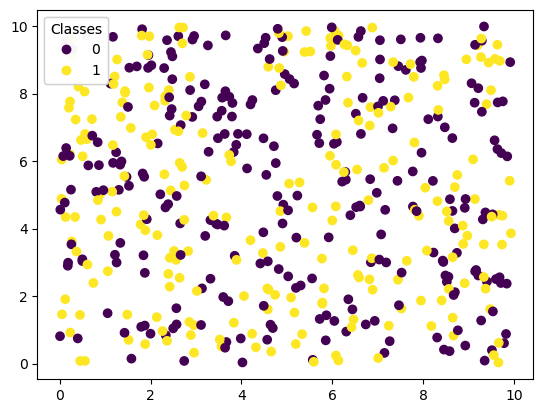

In [286]:
n = 500
x = np.random.uniform(low=0, high=10, size=n)
y = np.random.uniform(low=0, high=10, size=n)
d = np.random.randint(low=0, high=2, size=n)
df = pd.DataFrame({'x': x, 'y': y})
X, Z, y_train, y_test = train_test_split(df, d, test_size = 0.3, random_state=69)

fig, ax = plt.subplots()
scatter = ax.scatter(x, y, c = d)
legend1 = ax.legend(*scatter.legend_elements(),
                    loc="upper left", title="Classes")
ax.add_artist(legend1)

Odtwarzanie:

In [287]:
for p in [1, 2, np.inf]:
    unique, counts = np.unique(knn(X, y_train, X, 1, p) == y_train, return_counts=True)
    print(f"Stosunek poprawnych zaklasyfikowań dla p = {p}: {round(counts[1] / (counts[0] + counts[1]), 3)}")

Stosunek poprawnych zaklasyfikowań dla p = 1: 0.614
Stosunek poprawnych zaklasyfikowań dla p = 2: 0.614
Stosunek poprawnych zaklasyfikowań dla p = inf: 0.614


L1:

In [245]:
k_list = [1, 2, 5, 7, 10, 25, 35, 65, 100]
for k in k_list:
    unique, counts = np.unique(knn(X, y_train, Z, k, 1) == y_test, return_counts=True)
    print(f"Stosunek poprawnych zaklasyfikowań dla k = {k}: {round(counts[1] / (counts[0] + counts[1]), 3)}")

Stosunek poprawnych zaklasyfikowań dla k = 1: 0.527
Stosunek poprawnych zaklasyfikowań dla k = 2: 0.507
Stosunek poprawnych zaklasyfikowań dla k = 5: 0.467
Stosunek poprawnych zaklasyfikowań dla k = 7: 0.467
Stosunek poprawnych zaklasyfikowań dla k = 10: 0.48
Stosunek poprawnych zaklasyfikowań dla k = 25: 0.54
Stosunek poprawnych zaklasyfikowań dla k = 35: 0.52
Stosunek poprawnych zaklasyfikowań dla k = 65: 0.553
Stosunek poprawnych zaklasyfikowań dla k = 100: 0.547


L2:

In [246]:
k_list = [1, 2, 5, 7, 10, 25, 35, 65, 100]
for k in k_list:
    unique, counts = np.unique(knn(X, y_train, Z, k, 2) == y_test, return_counts=True)
    print(f"Stosunek poprawnych zaklasyfikowań dla k = {k}: {round(counts[1] / (counts[0] + counts[1]), 3)}")

Stosunek poprawnych zaklasyfikowań dla k = 1: 0.527
Stosunek poprawnych zaklasyfikowań dla k = 2: 0.487
Stosunek poprawnych zaklasyfikowań dla k = 5: 0.467
Stosunek poprawnych zaklasyfikowań dla k = 7: 0.467
Stosunek poprawnych zaklasyfikowań dla k = 10: 0.427
Stosunek poprawnych zaklasyfikowań dla k = 25: 0.54
Stosunek poprawnych zaklasyfikowań dla k = 35: 0.52
Stosunek poprawnych zaklasyfikowań dla k = 65: 0.553
Stosunek poprawnych zaklasyfikowań dla k = 100: 0.553


L_inf:

In [247]:
k_list = [1, 2, 5, 7, 10, 25, 35, 65, 100]
for k in k_list:
    unique, counts = np.unique(knn(X, y_train, Z, k, np.inf) == y_test, return_counts=True)
    print(f"Stosunek poprawnych zaklasyfikowań dla k = {k}: {round(counts[1] / (counts[0] + counts[1]), 3)}")

Stosunek poprawnych zaklasyfikowań dla k = 1: 0.527
Stosunek poprawnych zaklasyfikowań dla k = 2: 0.547
Stosunek poprawnych zaklasyfikowań dla k = 5: 0.46
Stosunek poprawnych zaklasyfikowań dla k = 7: 0.467
Stosunek poprawnych zaklasyfikowań dla k = 10: 0.48
Stosunek poprawnych zaklasyfikowań dla k = 25: 0.507
Stosunek poprawnych zaklasyfikowań dla k = 35: 0.527
Stosunek poprawnych zaklasyfikowań dla k = 65: 0.553
Stosunek poprawnych zaklasyfikowań dla k = 100: 0.553
